# ERCOT Load Forecasting

## 02 — Baseline Models

Goal: see how well simple models forecast hourly ERCOT load using only calendar features
and lagged load, and compare everything against a naive "same hour yesterday" baseline.

Data: `data/processed/model_data.csv`, produced by notebook 01. Development on 2022–2024,
final test on 2025 (never touched during training or tuning).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from xgboost import XGBRegressor

## 1. Load the processed data

One gotcha here: the saved timestamps carry Texas UTC offsets that change with daylight
saving time (`-06:00` in winter, `-05:00` in summer). `read_csv(parse_dates=...)` cannot
combine two different offsets into one datetime column, so it silently leaves the column
as plain strings — and date slicing on a string index quietly drops rows (`"2024-12-31"`
sorts *before* `"2024-12-31 01:00..."` as text, so `.loc[:"2024-12-31"]` lost all of
Dec 31, 2024). The fix: parse to UTC first, then convert to local time.

In [2]:
model_df = pd.read_csv("../data/processed/model_data.csv", index_col="timestamp")

# parse to UTC first (handles the mixed -06:00/-05:00 offsets), then back to local time
model_df.index = pd.to_datetime(model_df.index, utc=True).tz_convert("America/Chicago")

features = [
    "hour",
    "day_of_week",
    "month",
    "load_24h_ago",
    "load_168h_ago",
]

print(model_df.shape)
model_df.head()

(34896, 18)


,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,zone_sum,difference,is_dst,hour,day_of_week,month,load_24h_ago,load_168h_ago
timestamp,,,,,,,,,,,,,,,,,,
2022-01-08 01:00:00-06:00,01/08/2022 01:00,11111.168265,1509.047679,4267.173122,1034.819895,12591.052297,3208.802376,7187.517392,1167.575294,42077.156321,42077.156320,1.000000e-06,False,1,5,1,46656.525213,38006.938896
2022-01-08 02:00:00-06:00,01/08/2022 02:00,10810.296952,1472.793879,4273.766623,1015.021231,12205.638339,3091.975847,6944.302647,1141.767578,40955.563095,40955.563096,-1.000000e-06,False,2,5,1,46487.224472,37036.522365
2022-01-08 03:00:00-06:00,01/08/2022 03:00,10599.832180,1425.383989,4290.851418,998.102909,11970.673151,3019.330689,6745.663209,1123.545475,40173.383019,40173.383020,-1.000000e-06,False,3,5,1,46670.069636,35881.607998
2022-01-08 04:00:00-06:00,01/08/2022 04:00,10463.946202,1417.450072,4298.158460,991.914695,11871.295413,2995.933166,6669.413717,1110.960451,39819.072174,39819.072176,-1.999993e-06,False,4,5,1,47352.054871,35044.055105
2022-01-08 05:00:00-06:00,01/08/2022 05:00,10411.657216,1435.918305,4316.564249,996.509798,11953.131641,3003.206422,6621.475762,1107.944456,39846.407849,39846.407849,7.275958e-12,False,5,5,1,48710.924633,34585.571140


## 2. Chronological train/test split

Time series must be split by time, never randomly: with a random split, training rows
from 2025 would sit next to test rows from 2025 and the model could "see the future".
2022–2024 is the development data; 2025 is held back as the final test year.

In [3]:
# everything up to the end of 2024 for training, all of 2025 for the final test
train_df = model_df.loc[:"2024-12-31"]
test_df = model_df.loc["2025-01-01":]

In [4]:
X_train = train_df[features]
y_train = train_df["ERCOT"]

X_test = test_df[features]
y_test = test_df["ERCOT"]

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (26135, 5)
Test: (8761, 5)


## 3. Linear regression

Trained on 2022–2024. Both training and test errors are computed — a large gap between
them would be a sign of overfitting.

In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr = lr_model.predict(X_test)

lr_train_mae = mean_absolute_error(y_train, y_pred_lr_train)
lr_train_rmse = root_mean_squared_error(y_train, y_pred_lr_train)
lr_train_r2 = r2_score(y_train, y_pred_lr_train)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression - Training")
print("MAE:", lr_train_mae)
print("RMSE:", lr_train_rmse)
print("R2:", lr_train_r2)

print("\nLinear Regression - Test")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression - Training
MAE: 2292.041944749514
RMSE: 3286.7575302730197
R2: 0.911481874169645

Linear Regression - Test
MAE: 2397.0498706989224
RMSE: 3372.9766871600264
R2: 0.8893492710903108


In [6]:
for feature, coefficient in zip(features, lr_model.coef_):
    print(feature, coefficient)

print("Intercept:", lr_model.intercept_)

hour 22.970540237222682
day_of_week -296.49585151119646
month -14.167344903296133
load_24h_ago 0.8454395299474969
load_168h_ago 0.1196789610084818
Intercept: 2486.0705422640167


The coefficients are on unscaled features, so their sizes are not comparable with each
other — `hour` runs 0–23 while `load_24h_ago` is tens of thousands of MW. They show
direction, not importance.

## 4. Naive baseline

Any model has to beat "predict the same hour yesterday" (24-hour persistence) to justify
its complexity. Since `load_24h_ago` is already a column, the baseline prediction is free.

In [7]:
y_pred_baseline = X_test["load_24h_ago"]

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = root_mean_squared_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Naive Baseline")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2:", baseline_r2)

Naive Baseline
MAE: 2518.3207039629033
RMSE: 3607.49642078547
R2: 0.8734274825855979


## 5. Polynomial regression

Degree-2 polynomial features add squared terms and pairwise interactions, letting the
linear model bend a little. The features are standardized first so the squared terms
don't end up on wildly different scales.

In [8]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# fit the scaler on training data only, then apply it to both sets
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

poly_model = LinearRegression()
poly_model.fit(X_train_poly_scaled, y_train)

y_pred_poly_train = poly_model.predict(X_train_poly_scaled)
y_pred_poly = poly_model.predict(X_test_poly_scaled)

poly_train_mae = mean_absolute_error(y_train, y_pred_poly_train)
poly_train_rmse = root_mean_squared_error(y_train, y_pred_poly_train)
poly_train_r2 = r2_score(y_train, y_pred_poly_train)

poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_rmse = root_mean_squared_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression - Training")
print("MAE:", poly_train_mae)
print("RMSE:", poly_train_rmse)
print("R2:", poly_train_r2)

print("\nPolynomial Regression - Test")
print("MAE:", poly_mae)
print("RMSE:", poly_rmse)
print("R2:", poly_r2)

Polynomial Regression - Training
MAE: 2232.468102961277
RMSE: 3227.774343525351
R2: 0.9146304077035007

Polynomial Regression - Test
MAE: 2387.3525343748543
RMSE: 3383.5582613849133
R2: 0.8886539235698407


Adding second-order polynomial terms does not provide a meaningful improvement over
ordinary linear regression for this feature set.

## 6. Random forest

Tree ensembles have hyperparameters worth tuning, so this section uses a stricter split:
train on 2022–2023, validate on 2024, and leave 2025 completely untouched until tuning is
finished. Comparing training vs validation error shows how much the forest overfits.

In [9]:
# re-split the development years: train on 2022-2023, validate on 2024
# (test_df from above is unchanged and stays untouched until tuning is done)
train_df = model_df.loc[:"2023-12-31"]
val_df = model_df.loc["2024-01-01":"2024-12-31"]

X_train_rf = train_df[features]
y_train_rf = train_df["ERCOT"]

X_val_rf = val_df[features]
y_val_rf = val_df["ERCOT"]

X_test_rf = test_df[features]
y_test_rf = test_df["ERCOT"]

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

y_pred_rf_train = rf_model.predict(X_train_rf)
y_pred_rf_val = rf_model.predict(X_val_rf)

rf_train_mae = mean_absolute_error(y_train_rf, y_pred_rf_train)
rf_train_rmse = root_mean_squared_error(y_train_rf, y_pred_rf_train)
rf_train_r2 = r2_score(y_train_rf, y_pred_rf_train)

rf_val_mae = mean_absolute_error(y_val_rf, y_pred_rf_val)
rf_val_rmse = root_mean_squared_error(y_val_rf, y_pred_rf_val)
rf_val_r2 = r2_score(y_val_rf, y_pred_rf_val)

print("Random Forest - Training")
print("MAE:", rf_train_mae)
print("RMSE:", rf_train_rmse)
print("R2:", rf_train_r2)

print("\nRandom Forest - Validation")
print("MAE:", rf_val_mae)
print("RMSE:", rf_val_rmse)
print("R2:", rf_val_r2)

Random Forest - Training
MAE: 1806.9927209917848
RMSE: 2580.020012633157
R2: 0.9470164724439154

Random Forest - Validation
MAE: 2339.687200603283
RMSE: 3427.0939868230926
R2: 0.8937155766098466


## 7. Time-series cross-validation

A single validation year is only one sample of model performance. `TimeSeriesSplit` gives
several train/validation folds while always training on the past and validating on the
future — fold 1 trains on the earliest chunk of data, the last fold trains on almost all
of the development data.

In [10]:
# development data = everything before the 2025 test year
dev_df = model_df.loc[:"2024-12-31"]

X_dev = dev_df[features]
y_dev = dev_df["ERCOT"]

tscv = TimeSeriesSplit(n_splits=3)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)

scores = cross_validate(
    rf_model,
    X_dev,
    y_dev,
    cv=tscv,
    scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
)

# sklearn reports errors as negative values (so that higher = better), flip the sign back
mae_scores = -scores["test_neg_mean_absolute_error"]
rmse_scores = -scores["test_neg_root_mean_squared_error"]
r2_scores = scores["test_r2"]

print("MAE per fold:", mae_scores)
print("RMSE per fold:", rmse_scores)
print("R2 per fold:", r2_scores)

print("\nAverage MAE:", mae_scores.mean())
print("Average RMSE:", rmse_scores.mean())
print("Average R2:", r2_scores.mean())

MAE per fold: [2519.45040805 2293.84610755 2171.74717039]
RMSE per fold: [3566.6417124  3357.35557089 3050.32354447]
R2 per fold: [0.83451645 0.91896499 0.91800216]

Average MAE: 2328.3478953320373
Average RMSE: 3324.773609254571
Average R2: 0.890494533427252


## 8. Hyperparameter tuning with GridSearchCV

`GridSearchCV` tries every combination in the grid, scores each one with the same
time-series folds, and (because `refit=True`) retrains the best combination on all of the
development data. Only that final model gets to see the 2025 test set.

In [11]:
rf_model = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 10, 12],
    "min_samples_leaf": [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

grid_search.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_rf)

rf_test_mae = mean_absolute_error(y_test_rf, y_pred_rf)
rf_test_rmse = root_mean_squared_error(y_test_rf, y_pred_rf)
rf_test_r2 = r2_score(y_test_rf, y_pred_rf)

print("\nTuned Random Forest - Test")
print("MAE:", rf_test_mae)
print("RMSE:", rf_test_rmse)
print("R2:", rf_test_r2)

Best parameters:
{'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 200}

Best CV RMSE:
3277.8209887148173

Tuned Random Forest - Test
MAE: 2382.4213374370033
RMSE: 3399.918485587627
R2: 0.8875745564312711


## 9. Gradient boosting

Boosting builds shallow trees one after another, each new tree correcting the errors of
the ones before it. It is usually stronger than a random forest on tabular data but more
sensitive to the learning rate.

In [12]:
gb_model = GradientBoostingRegressor(random_state=42)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 14],
}

grid_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

grid_gb.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_gb.best_params_)

print("\nBest CV RMSE:")
print(-grid_gb.best_score_)

best_gb = grid_gb.best_estimator_
y_pred_gb_test = best_gb.predict(X_test_rf)

gb_test_mae = mean_absolute_error(y_test_rf, y_pred_gb_test)
gb_test_rmse = root_mean_squared_error(y_test_rf, y_pred_gb_test)
gb_test_r2 = r2_score(y_test_rf, y_pred_gb_test)

print("\nTuned Gradient Boosting - Test")
print("MAE:", gb_test_mae)
print("RMSE:", gb_test_rmse)
print("R2:", gb_test_r2)

Best parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 14, 'n_estimators': 200}

Best CV RMSE:
3176.0229363897474

Tuned Gradient Boosting - Test
MAE: 2330.2970025367895
RMSE: 3331.848510791334
R2: 0.8920312447807672


## 10. XGBoost

XGBoost is a heavily optimized gradient-boosting implementation. `subsample` and
`colsample_bytree` add extra regularization by training each tree on a random subset of
the rows and columns.

In [13]:
xgb_model = XGBRegressor(random_state=42)

param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)

grid_xgb.fit(X_dev, y_dev)

print("Best parameters:")
print(grid_xgb.best_params_)

print("\nBest CV RMSE:")
print(-grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb_test = best_xgb.predict(X_test_rf)

xgb_test_mae = mean_absolute_error(y_test_rf, y_pred_xgb_test)
xgb_test_rmse = root_mean_squared_error(y_test_rf, y_pred_xgb_test)
xgb_test_r2 = r2_score(y_test_rf, y_pred_xgb_test)

print("\nTuned XGBoost - Test")
print("MAE:", xgb_test_mae)
print("RMSE:", xgb_test_rmse)
print("R2:", xgb_test_r2)

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}

Best CV RMSE:
3185.3389058336784

Tuned XGBoost - Test
MAE: 2319.771450357893
RMSE: 3319.61300005175
R2: 0.8928227736967924


## 11. Model comparison on the 2025 test set

One table with every model's final test metrics, built from the variables computed above.

In [14]:
model_summary = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Polynomial Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
    ],
    "MAE": [baseline_mae, lr_mae, poly_mae, rf_test_mae, gb_test_mae, xgb_test_mae],
    "RMSE": [baseline_rmse, lr_rmse, poly_rmse, rf_test_rmse, gb_test_rmse, xgb_test_rmse],
    "R2": [baseline_r2, lr_r2, poly_r2, rf_test_r2, gb_test_r2, xgb_test_r2],
})

model_summary.round(3)

,Model,MAE,RMSE,R2
0,Naive Baseline,2518.321,3607.496,0.873
1,Linear Regression,2397.050,3372.977,0.889
2,Polynomial Regression,2387.353,3383.558,0.889
3,Random Forest,2382.421,3399.918,0.888
4,Gradient Boosting,2330.297,3331.849,0.892
5,XGBoost,2319.771,3319.613,0.893


## 12. Error analysis

Aggregate metrics hide *where* the model fails. Looking at the worst individual hours and
how the error varies over time and hour of day suggests what feature to add next. The
analysis below uses the best model (XGBoost).

In [15]:
results = pd.DataFrame({
    "actual": y_test_rf,
    "predicted": y_pred_xgb_test,
})

results["error"] = results["actual"] - results["predicted"]
results["abs_error"] = results["error"].abs()

# the ten hours where the forecast was furthest off
results.sort_values("abs_error", ascending=False).head(10)

,actual,predicted,error,abs_error
timestamp,,,,
2025-02-19 12:00:00-06:00,76886.704538,51168.847656,25717.856882,25717.856882
2025-02-19 11:00:00-06:00,76768.481000,51119.328125,25649.152875,25649.152875
2025-02-19 10:00:00-06:00,76051.042809,50929.027344,25122.015465,25122.015465
2025-02-19 13:00:00-06:00,76379.458848,51330.523438,25048.935410,25048.935410
2025-02-19 09:00:00-06:00,75492.524547,50847.472656,24645.051891,24645.051891
2025-01-06 08:00:00-06:00,67859.426820,44005.554688,23853.872132,23853.872132
2025-02-19 08:00:00-06:00,74507.457153,50724.792969,23782.664184,23782.664184
2025-02-19 14:00:00-06:00,75573.071923,52278.335938,23294.735985,23294.735985
2025-01-06 09:00:00-06:00,67824.975283,45310.468750,22514.506533,22514.506533


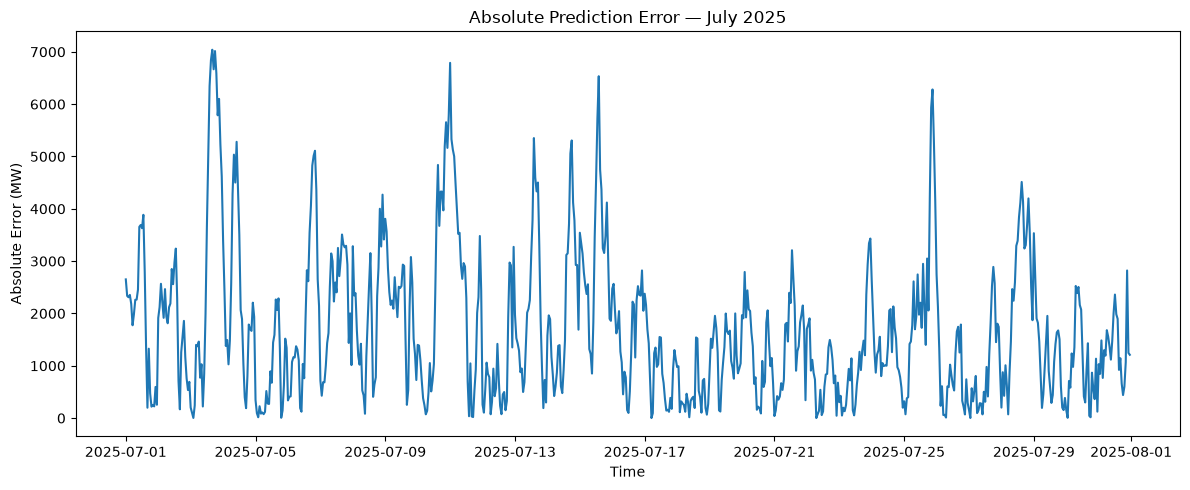

In [16]:
# zoom in on one summer month (the index is a proper DatetimeIndex, so this just works)
july = results.loc["2025-07"]

plt.figure(figsize=(12, 5))
plt.plot(july.index, july["abs_error"])

plt.xlabel("Time")
plt.ylabel("Absolute Error (MW)")
plt.title("Absolute Prediction Error — July 2025")

plt.tight_layout()
plt.show()

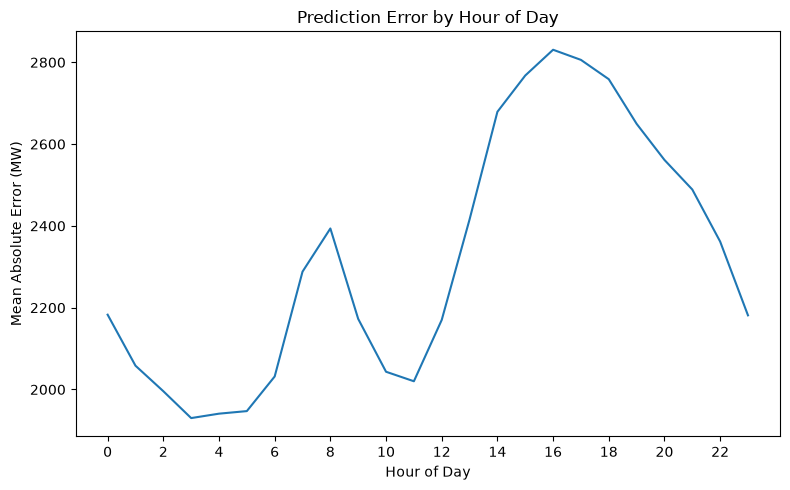

In [17]:
results["hour"] = results.index.hour

error_by_hour = results.groupby("hour")["abs_error"].mean()

plt.figure(figsize=(8, 5))
plt.plot(error_by_hour.index, error_by_hour.values)

plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error (MW)")
plt.title("Prediction Error by Hour of Day")

plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

## 13. Feature importance

XGBoost's feature importance measures how much the trees rely on each feature — it
describes what the model uses, not what causes electricity demand.

load_24h_ago     0.886167
load_168h_ago    0.084314
day_of_week      0.012279
hour             0.009965
month            0.007275
dtype: float32


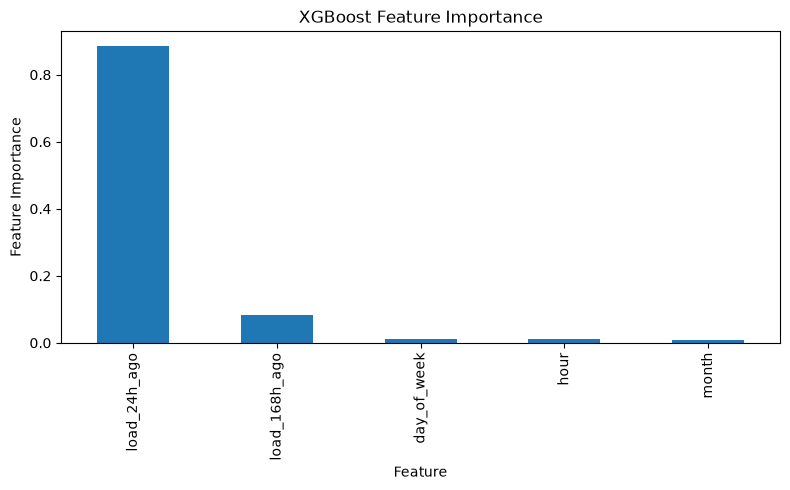

In [18]:
importance = pd.Series(best_xgb.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8, 5))
importance.plot(kind="bar")

plt.xlabel("Feature")
plt.ylabel("Feature Importance")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

XGBoost feature importance shows that the 24-hour lag is the dominant predictor of ERCOT load, followed by the one-week lag. Calendar variables contribute comparatively less, indicating that recent demand history carries most of the predictive signal in the current feature set.